# More optimal control problems


$$
\newcommand{\eg}{{\it e.g.}}
\newcommand{\ie}{{\it i.e.}}
\newcommand{\argmin}{\operatornamewithlimits{argmin}}
\newcommand{\mc}{\mathcal}
\newcommand{\mb}{\mathbb}
\newcommand{\mf}{\mathbf}
\newcommand{\minimize}{{\text{minimize}}}
\newcommand{\diag}{{\text{diag}}}
\newcommand{\cond}{{\text{cond}}}
\newcommand{\rank}{{\text{rank }}}
\newcommand{\range}{{\mathcal{R}}}
\newcommand{\null}{{\mathcal{N}}}
\newcommand{\tr}{{\text{trace}}}
\newcommand{\dom}{{\text{dom}}}
\newcommand{\dist}{{\text{dist}}}
\newcommand{\R}{\mathbf{R}}
\newcommand{\SM}{\mathbf{S}}
\newcommand{\ball}{\mathcal{B}}
\newcommand{\bmat}[1]{\begin{bmatrix}#1\end{bmatrix}}
$$

__<div style="text-align: right"> ASE7030: Convex Optimization, Inha University. </div>__
_<div style="text-align: right"> Jong-Han Kim (jonghank@inha.ac.kr) </div>_


<br>

This note talks about variations of optimal control problems with different objective functions and constraints.

A discrete-time linear dynamical system consists of a sequence of state vectors $x_t \in \R^n$, indexed by time $t\in \{0,\dots,N-1\}$ and dynamics equations

$$
\begin{aligned}
  x_{t+1} &= Ax_t + Bu_t
\end{aligned}
$$

where $u_t\in\R^m$ is a control input to the dynamical system (say, a drive force or steering force on the vehicle). $A$ is the state transition matrix, $B$ is the input matrix.

Given $A$ and $B$, the goal is to find the optimal $u_0, \dots, u_{N-1}$ that drives the systems state to the desirable state. The optimality now can be described in a variety of more complicated convex functions and constraints.


<br>

---

## Minimum energy control revisited

Recall the minimum energy control problem which was described as follows.

$$
\begin{aligned}
  \underset{u}{\minimize} \quad & \sum_{t=0}^{N-1} \|u_t\|_2^2  \\
  \text{subject to} \quad & x_N = x_{\text{des}} \\
  \quad & x_{t+1} = Ax_t + Bu_t, \qquad & t=0,\dots,N-1
\end{aligned}
$$



We'll consider optimal vehicle guidance problem with state $x_t\in\R^4$, where the first two states are the position of the vehicle in two dimensions, and the last two are the vehicle velocity. The vehicle's control force $u_t\in\R^2$ is acceleration control for the two axes.

Then the following matrices describe the above dynamics.

$$
A = \bmat{
1 & 0 & \left(1-0.5\gamma\Delta t\right)\Delta t & 0 \\
0 & 1 & 0 & \left(1-0.5\gamma\Delta t\right)\Delta t \\
0 & 0 & 1-\gamma\Delta t & 0 \\
0 & 0 & 0 & 1-\gamma\Delta t
} \\
B = \bmat{
0.5\Delta t^2 & 0 \\
0 & 0.5\Delta t^2 \\
\Delta t & 0 \\
0 & \Delta t
}
$$

We consider the finite horizon of $T=50$, with $\Delta t=0.05$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000 # number of timesteps
T = 50 # time will vary from 0 to T with step delt
ts = np.linspace(0,T,N+1)
delt = T/N
gamma = .05 # damping, 0 is no damping

A = np.zeros((4,4))
B = np.zeros((4,2))
C = np.zeros((2,4))

A[0,0] = 1
A[1,1] = 1
A[0,2] = (1-gamma*delt/2)*delt
A[1,3] = (1-gamma*delt/2)*delt
A[2,2] = 1 - gamma*delt
A[3,3] = 1 - gamma*delt

B[0,0] = delt**2/2
B[1,1] = delt**2/2
B[2,0] = delt
B[3,1] = delt

<br>

You may recall that we used the constraints describing the dynamical relations, $x_{t+1} = Ax_t + Bu_t$ in order to eleminate the state variables, $x_1, \dots,x_N$, from the optimization problem. That way we were able to express the problem as a standard form least norm problem with the optimization variable $u_0,\dots,u_{N-1}$. The resulting problem looked like

$$
\begin{aligned}
  \underset{u}{\minimize} \quad & \|u\|_2^2 \\
  \text{subject to} \quad & Gu = x_\text{des}-A^Nx_0
\end{aligned}
$$

where $G=\bmat{A^{N-1}B & A^{N-2}B & \cdots & AB & B}$ and $u=\bmat{u_1^T & \cdots & u_{N-1}^T}^T$. The desired final position and velocity vector is expressed in $x_\text{des}$ and $x_0$ describes the initial condition.

The following was an implementation of this idea.

In [2]:
import scipy.sparse as ssp
import scipy.sparse.linalg as sla

x_0 = np.array([10, -20, 15, -5])
x_des = np.array([100, 50, 0, 0])

G = np.zeros((4,2*N))

for i in range(N):
  G[:, 2*i:2*(i+1)] = np.linalg.matrix_power(A,max(0,N-i-1))@B

u_hat = sla.lsqr(G,x_des - np.linalg.matrix_power(A,N)@x_0)[0]

u_vec = u_hat

u_opt = u_vec.reshape(1000,2).T

x_opt = np.zeros((4,N+1))
x_opt[:,0] = x_0

for t in range(N):
    x_opt[:,t+1] = A.dot(x_opt[:,t]) + B.dot(u_opt[:,t])

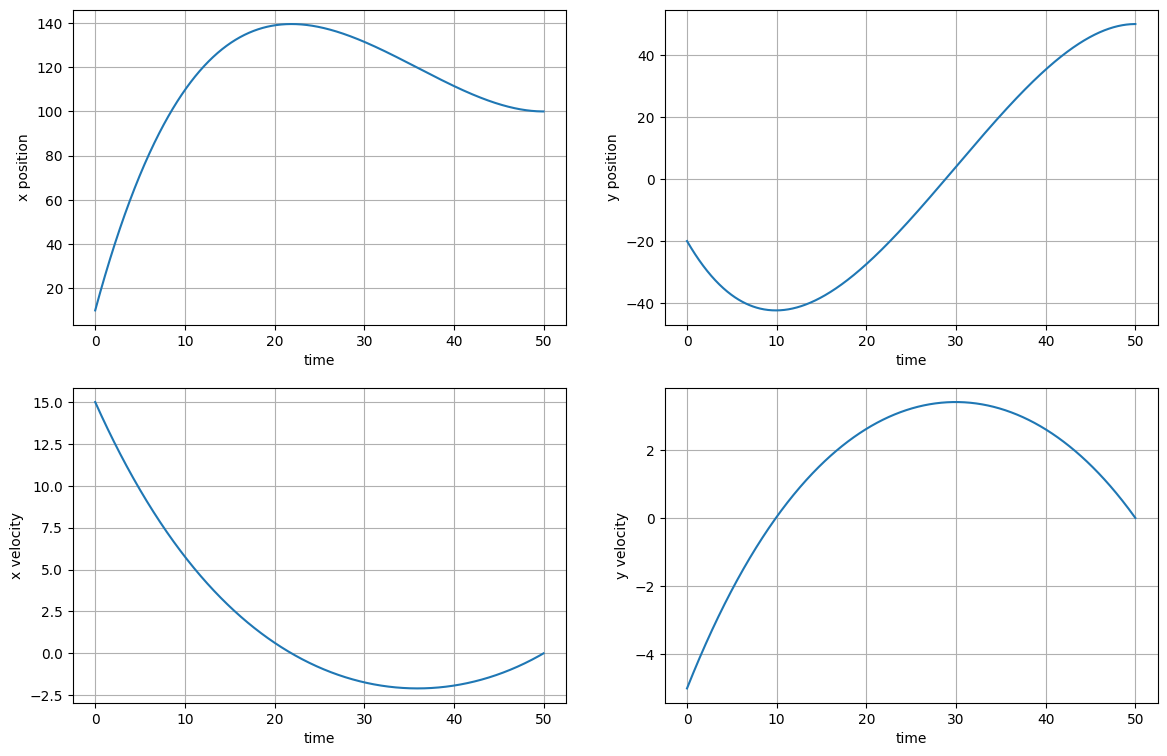

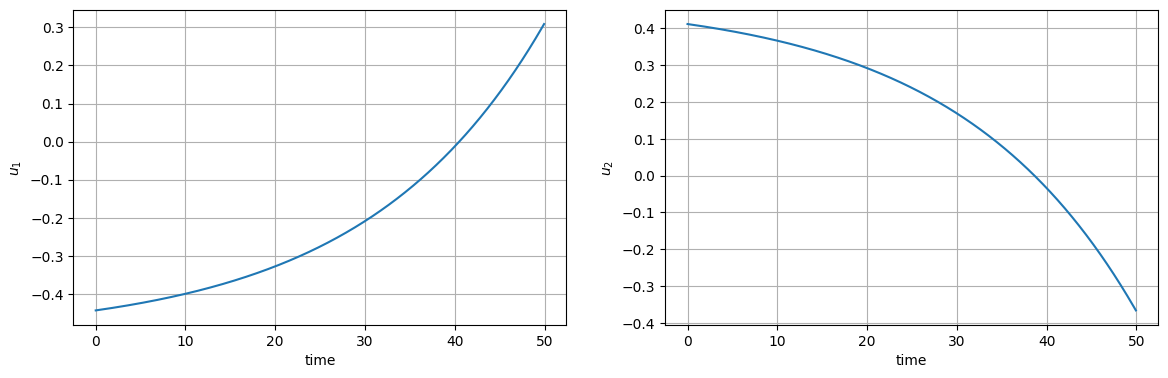

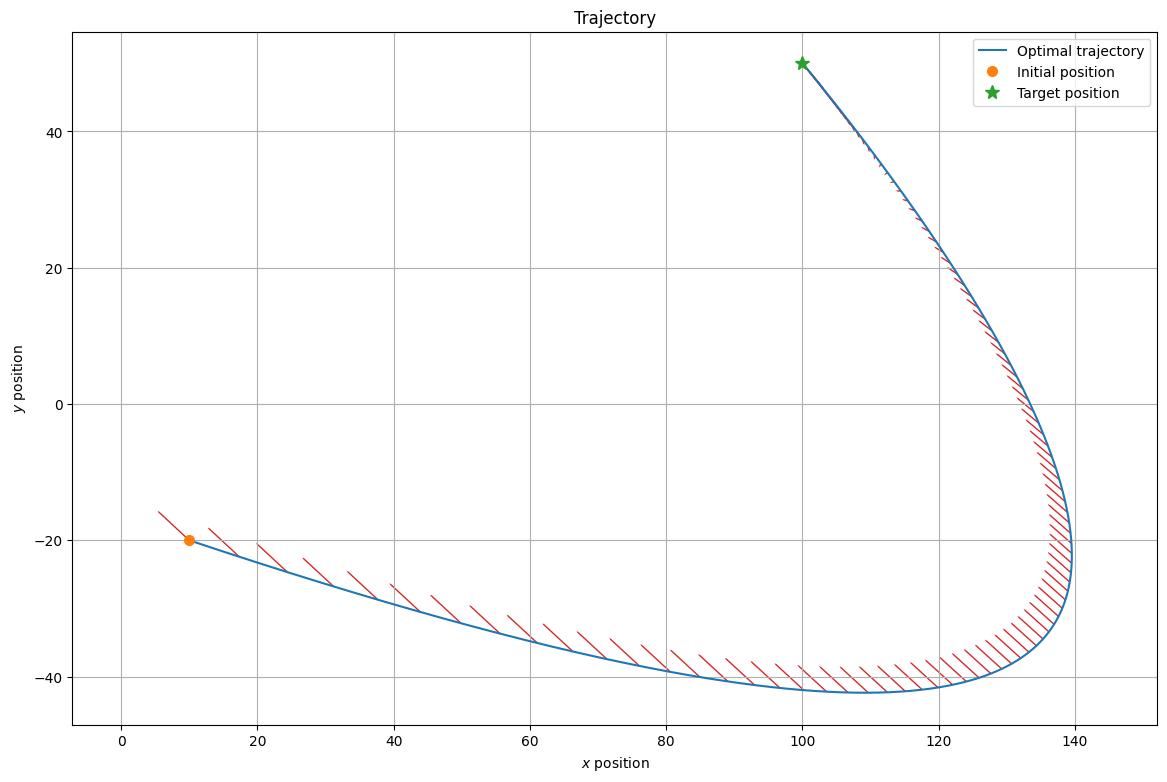

In [3]:
plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts,x_opt[0,:])
plt.xlabel('time')
plt.ylabel('x position')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts,x_opt[1,:])
plt.xlabel('time')
plt.ylabel('y position')
plt.grid()
plt.subplot(2,2,3)
plt.plot(ts,x_opt[2,:])
plt.xlabel('time')
plt.ylabel('x velocity')
plt.grid()
plt.subplot(2,2,4)
plt.plot(ts,x_opt[3,:])
plt.xlabel('time')
plt.ylabel('y velocity')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts[:-1],u_opt[0,:])
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts[:-1],u_opt[1,:])
plt.xlabel('time')
plt.ylabel(r'$u_2$')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.plot(x_opt[0,:],x_opt[1,:], label='Optimal trajectory')
plt.plot(x_0[0], x_0[1], 'o', markersize=7, label='Initial position')
plt.plot(x_des[0], x_des[1], '*', markersize=10, label='Target position')
plt.title('Trajectory')
plt.legend()
for i in range(0,N-1,10):
  plt.arrow(x_opt[0,i], x_opt[1,i], 10*u_opt[0,i], 10*u_opt[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none')
plt.axis('equal')
plt.xlabel(r'$x$ position')
plt.ylabel(r'$y$ position')
plt.grid()
plt.show()

<br>

---

## Minimum energy control with `cvxpy`

But we will not do this today. Instead, we will just use the original non-standard form with the optimization variables $u_0,\dots,u_{N-1}, x_1,\dots,x_N$, and the original dynamic constraints as linear equality constraints on the optimization variables.

$$
\begin{aligned}
  \underset{u_0,\dots,u_{N-1}, x_1,\dots,x_N}{\minimize} \quad & \sum_{t=0}^{N-1} \|u_t\|_2^2  \\
  \text{subject to} \quad & x_N = x_{\text{des}} \\
  \quad & x_{t+1} = Ax_t + Bu_t, \qquad & t=0,\dots,N-1
\end{aligned}
$$

We will just put this form into `cvxpy`.


In [4]:
import cvxpy as cp

x = cp.Variable((4,N+1))  # x_{0},...,x_{N}
u = cp.Variable((2,N))    # u_{0},...,u_{N-1}

obj = cp.Minimize(cp.sum_squares(u))

constr = [ x[:,-1] == x_des,
           x[:,0]  == x_0    ]
for t in range(N):
    constr += [ x[:,t+1] == A@x[:,t] + B@u[:,t] ]

cp.Problem(obj, constr).solve(verbose=True)

x_cp = np.array(x.value)
u_cp = np.array(u.value)

(CVXPY) May 18 02:26:43 PM: Your problem has 6004 variables, 4008 constraints, and 0 parameters.
(CVXPY) May 18 02:26:43 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 18 02:26:43 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 18 02:26:43 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 18 02:26:43 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) May 18 02:26:43 PM: Compiling problem (target solver=OSQP).
(CVXPY) May 18 02:26:43 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) May 18 02:26:43 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 18 02:26:43 PM: Applying reduction Qp2SymbolicQp
(CVXPY) May 18 02:26:43 PM: Applying reduction QpMatrixStuffing


                                     CVXPY                                     
                                     v1.7.3                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 18 02:26:44 PM: Applying reduction OSQP
(CVXPY) May 18 02:26:44 PM: Finished problem compilation (took 6.488e-01 seconds).
(CVXPY) May 18 02:26:44 PM: Invoking solver OSQP  to obtain a solution.
(CVXPY) May 18 02:26:44 PM: Problem status: optimal
(CVXPY) May 18 02:26:44 PM: Optimal value: 1.616e+02
(CVXPY) May 18 02:26:44 PM: Compilation took 6.488e-01 seconds
(CVXPY) May 18 02:26:44 PM: Solver (including time spent in interface) took 1.600e-02 seconds


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 6004, constraints m = 4008
          nnz(P) + nnz(A) = 16008
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-05, eps_rel = 1.0e-05,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 10000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
 

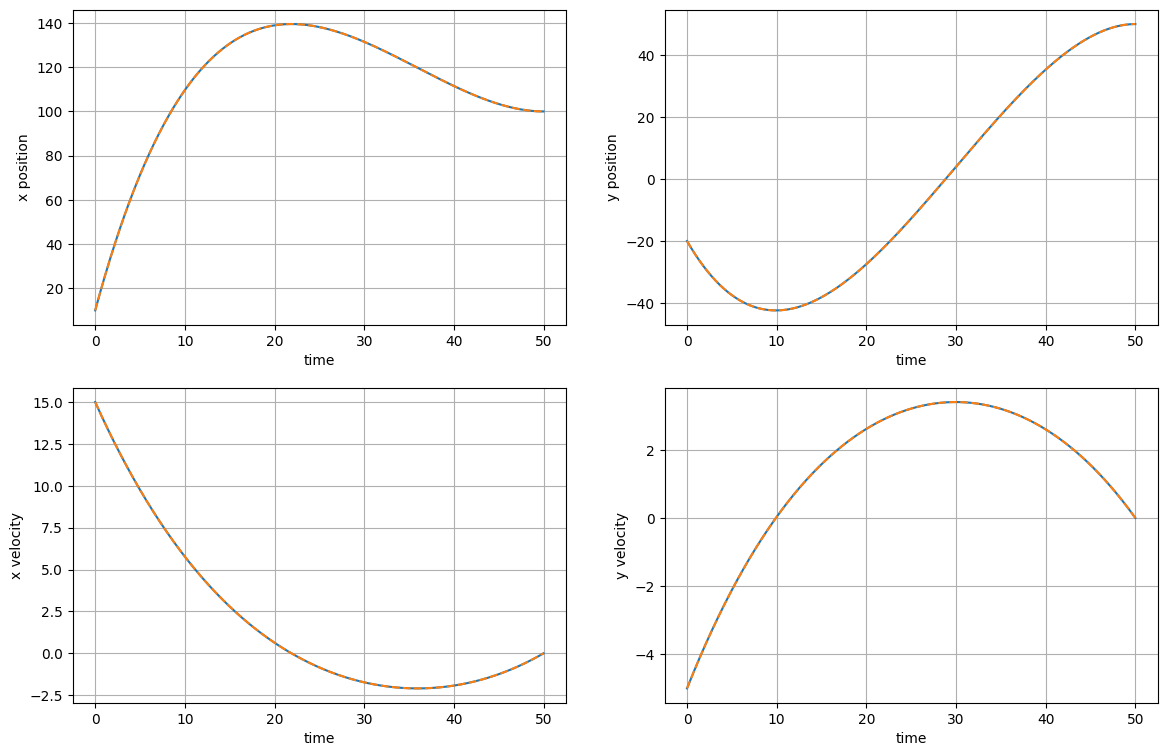

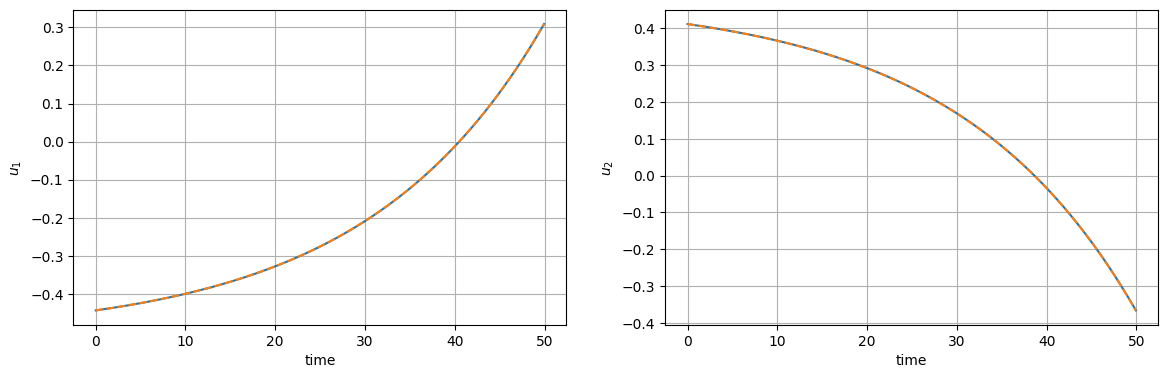

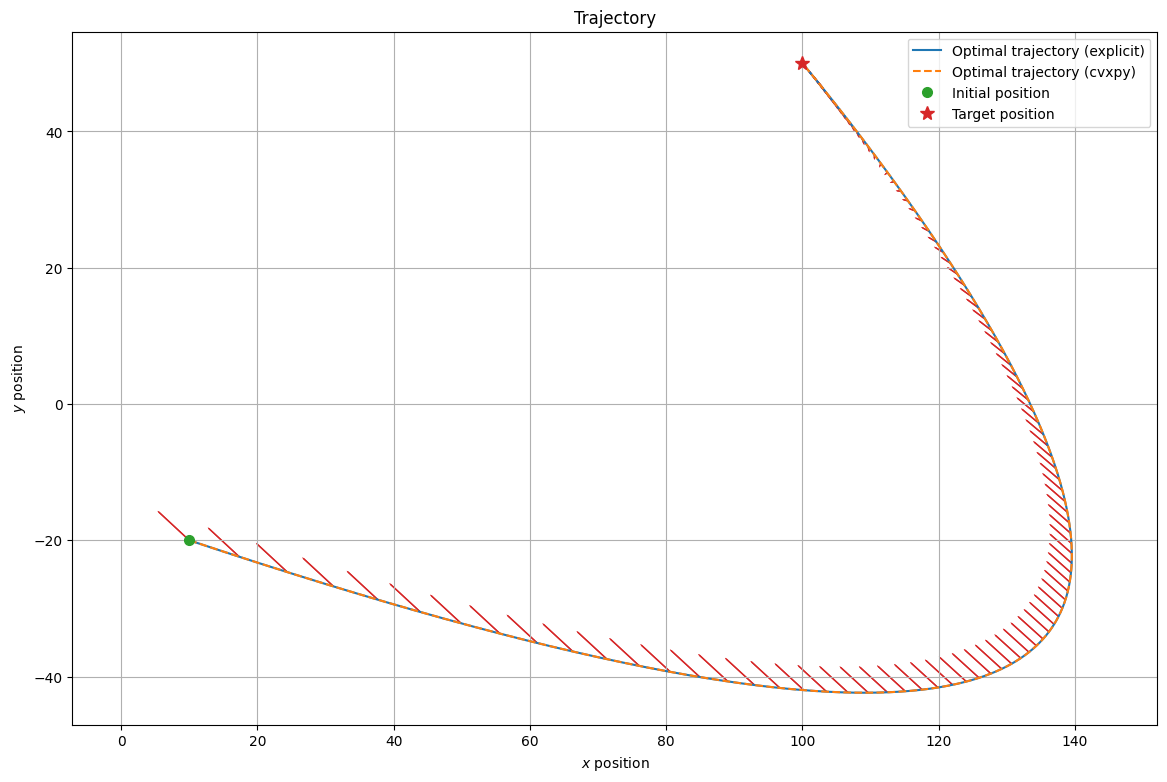

In [5]:
plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts,x_opt[0,:])
plt.plot(ts,x_cp[0,:], '--')
plt.xlabel('time')
plt.ylabel('x position')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts,x_opt[1,:])
plt.plot(ts,x_cp[1,:], '--')
plt.xlabel('time')
plt.ylabel('y position')
plt.grid()
plt.subplot(2,2,3)
plt.plot(ts,x_opt[2,:])
plt.plot(ts,x_cp[2,:], '--')
plt.xlabel('time')
plt.ylabel('x velocity')
plt.grid()
plt.subplot(2,2,4)
plt.plot(ts,x_opt[3,:])
plt.plot(ts,x_cp[3,:], '--')
plt.xlabel('time')
plt.ylabel('y velocity')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts[:-1],u_opt[0,:])
plt.plot(ts[:-1],u_cp[0,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts[:-1],u_opt[1,:])
plt.plot(ts[:-1],u_cp[1,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_2$')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.plot(x_opt[0,:],x_opt[1,:], label='Optimal trajectory (explicit)')
plt.plot(x_cp[0,:],x_cp[1,:], '--', label='Optimal trajectory (cvxpy)')
plt.plot(x_0[0], x_0[1], 'o', markersize=7, label='Initial position')
plt.plot(x_des[0], x_des[1], '*', markersize=10, label='Target position')
plt.title('Trajectory')
plt.legend()
for i in range(0,N-1,10):
  plt.arrow(x_opt[0,i], x_opt[1,i], 10*u_opt[0,i], 10*u_opt[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none')
  plt.arrow(x_cp[0,i], x_cp[1,i], 10*u_cp[0,i], 10*u_cp[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none')
plt.axis('equal')
plt.xlabel(r'$x$ position')
plt.ylabel(r'$y$ position')
plt.grid()
plt.show()

So they just overlap. Someone with an accuracy-OCD could check the followings.

In [6]:
x_diff = x_cp - x_opt
u_diff = u_cp - u_opt

print (np.linalg.norm(x_diff))
print (np.linalg.norm(u_diff))

1.6663590793632668e-06
1.9535050360103523e-08


<br>

---

## Minimum energy control with state limits

Suppose your vehicle is limited to move inside some rectangular area. It is like your robot vaccum searching for the minimum energy trajectory inside your (rectangular) room.

So the problem can be described by

$$
\begin{aligned}
  \underset{u_0,\dots,u_{N-1}, x_1,\dots,x_N}{\minimize} \quad & \sum_{t=0}^{N-1} \|u_t\|_2^2  \\
  \text{subject to} \quad & x_N = x_{\text{des}} \\
  \quad & x_{t+1} = Ax_t + Bu_t, \qquad & t=0,\dots,N-1 \\
  & p_\text{lb} \le C x_t \le p_\text{ub}, \qquad & t=1,\dots,N
\end{aligned}
$$

where $C$ chooses the position vector from a state variable,

$$
  C = \bmat{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0}
$$

and $p_\text{lb}$ and $p_\text{ub}$ describe the boundary of the rectangle.


In [7]:
import cvxpy as cp

##########################################
p_lb = np.array([  0, -35])
p_ub = np.array([115,  70])
C = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
##########################################

x = cp.Variable((4,N+1))  # x_{0},...,x_{N}
u = cp.Variable((2,N))    # u_{0},...,u_{N-1}

obj = cp.Minimize(cp.sum_squares(u))

constr = [ x[:,-1] == x_des,
           x[:,0]  == x_0    ]
for t in range(N):
    constr += [ x[:,t+1] == A@x[:,t] + B@u[:,t] ]
    ####################################################
    constr += [ p_lb <= C@x[:,t+1], C@x[:,t+1] <= p_ub ]
    ####################################################

cp.Problem(obj, constr).solve(verbose=True)

x_cp = np.array(x.value)
u_cp = np.array(u.value)

(CVXPY) May 18 02:26:44 PM: Your problem has 6004 variables, 8008 constraints, and 0 parameters.
(CVXPY) May 18 02:26:44 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 18 02:26:44 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 18 02:26:44 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 18 02:26:44 PM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.7.3                                    


(CVXPY) May 18 02:26:45 PM: Compiling problem (target solver=OSQP).
(CVXPY) May 18 02:26:45 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) May 18 02:26:45 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 18 02:26:45 PM: Applying reduction Qp2SymbolicQp
(CVXPY) May 18 02:26:45 PM: Applying reduction QpMatrixStuffing


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 18 02:26:46 PM: Applying reduction OSQP
(CVXPY) May 18 02:26:46 PM: Finished problem compilation (took 1.416e+00 seconds).
(CVXPY) May 18 02:26:46 PM: Invoking solver OSQP  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 6004, constraints m = 8008
          nnz(P) + nnz(A) = 20008
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-05, eps_rel = 1.0e-05,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 10000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
 

(CVXPY) May 18 02:26:46 PM: Problem status: optimal
(CVXPY) May 18 02:26:46 PM: Optimal value: 1.942e+02
(CVXPY) May 18 02:26:46 PM: Compilation took 1.416e+00 seconds
(CVXPY) May 18 02:26:46 PM: Solver (including time spent in interface) took 3.647e-01 seconds


1350   1.9419e+02   2.43e-02   7.79e-06   1.41e-01   1.41e-01   2.29e-02*   2.07e-01s
1400   1.9420e+02   1.87e-02   3.61e-04   5.87e-01   5.87e-01   2.29e-02    2.15e-01s
1600   1.9420e+02   1.21e-02   5.27e-06  -1.98e-02   1.21e-02   2.29e-02    2.46e-01s
1700   1.9421e+02   9.07e-03   2.21e-06  -1.67e-04   9.07e-03   1.47e-01*   2.61e-01s
1800   1.9422e+02   6.25e-03   2.56e-06  -3.95e-02   6.25e-03   1.47e-01    2.76e-01s
1900   1.9422e+02   4.05e-03   1.28e-06  -2.95e-02   4.05e-03   8.26e-01*   2.91e-01s
2000   1.9423e+02   1.62e-03   1.60e-03   9.52e-02   9.52e-02   8.33e-02*   3.06e-01s
2100   1.9423e+02   1.90e-03   3.91e-07  -1.25e-02   1.90e-03   5.81e-01*   3.21e-01s
2200   1.9423e+02   1.01e-03   7.77e-06   2.13e-02   2.13e-02   5.81e-01    3.36e-01s
2375   1.9423e+02   1.03e-03   2.71e-06  -3.44e-03   1.03e-03   5.81e-01    3.61e-01s

status:               solved
solution polishing:   unsuccessful
number of iterations: 2375
optimal objective:    194.2285
dual objective:  

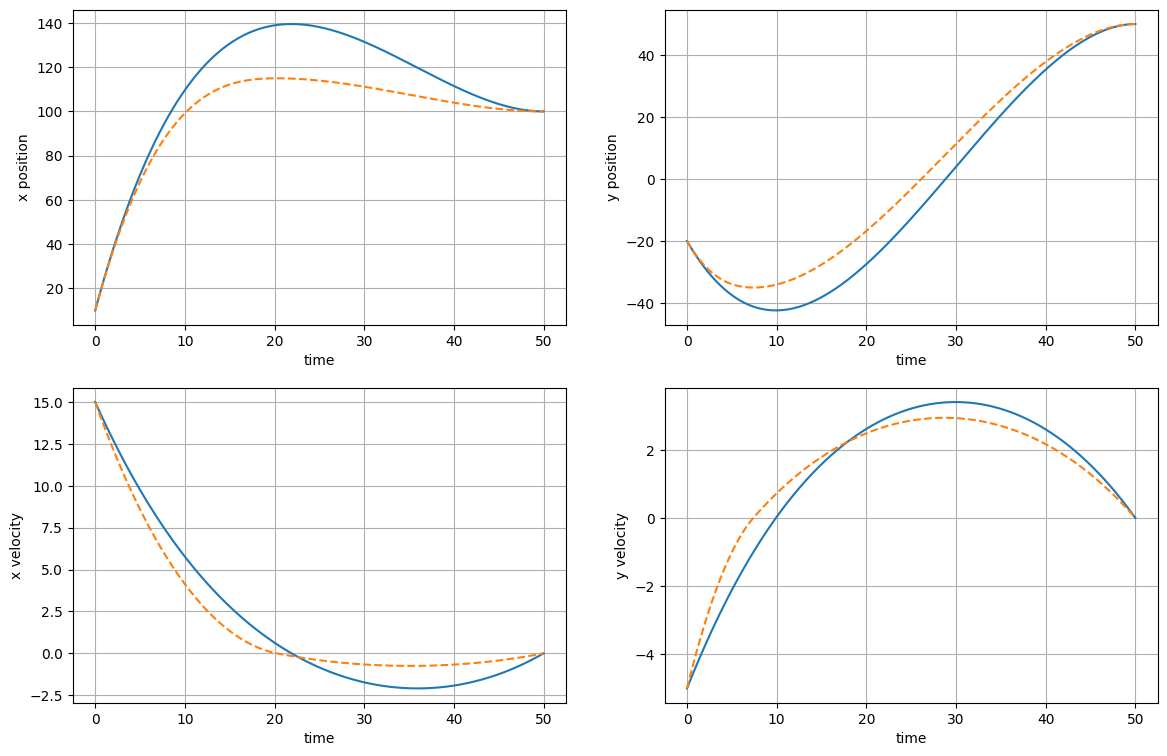

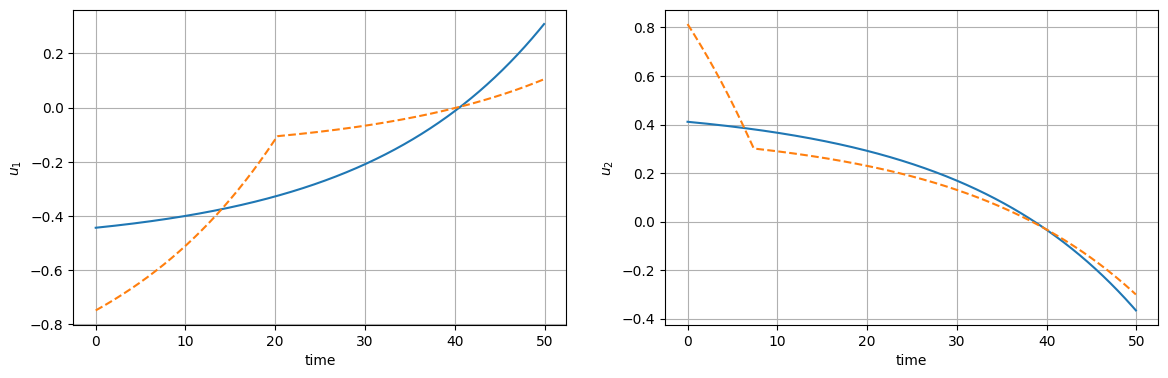

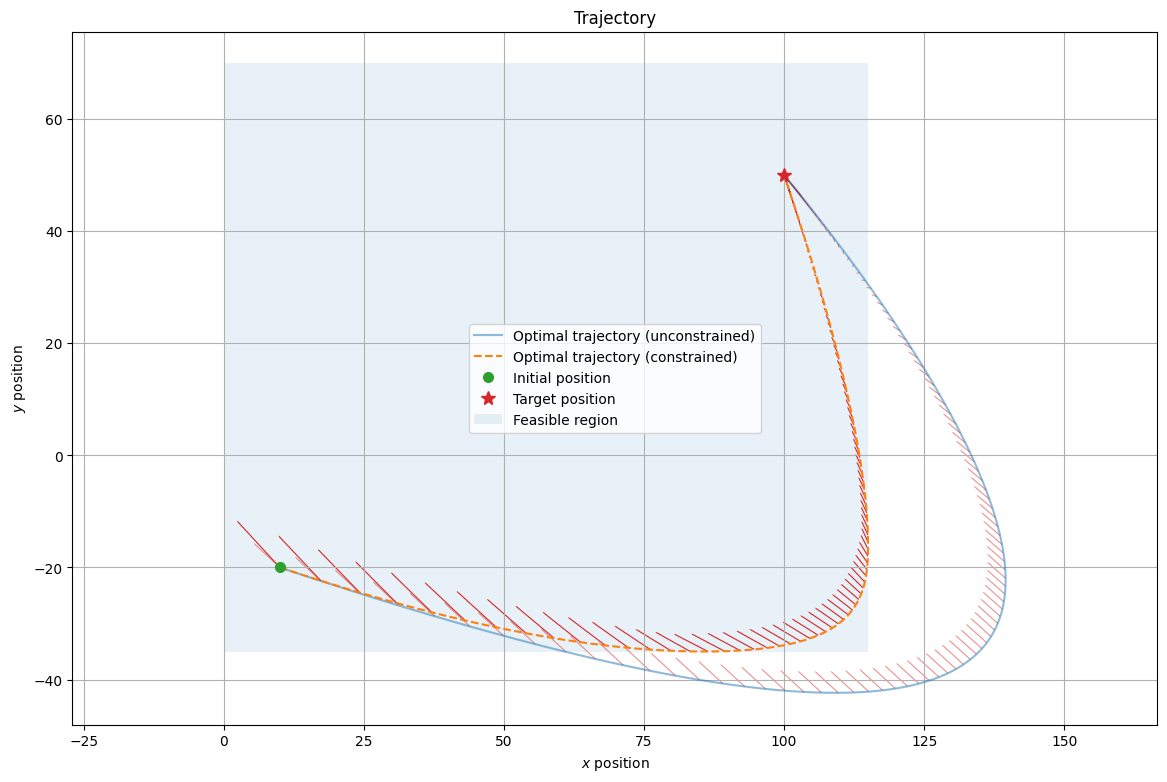

In [8]:
plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts,x_opt[0,:])
plt.plot(ts,x_cp[0,:], '--')
plt.xlabel('time')
plt.ylabel('x position')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts,x_opt[1,:])
plt.plot(ts,x_cp[1,:], '--')
plt.xlabel('time')
plt.ylabel('y position')
plt.grid()
plt.subplot(2,2,3)
plt.plot(ts,x_opt[2,:])
plt.plot(ts,x_cp[2,:], '--')
plt.xlabel('time')
plt.ylabel('x velocity')
plt.grid()
plt.subplot(2,2,4)
plt.plot(ts,x_opt[3,:])
plt.plot(ts,x_cp[3,:], '--')
plt.xlabel('time')
plt.ylabel('y velocity')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts[:-1],u_opt[0,:])
plt.plot(ts[:-1],u_cp[0,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts[:-1],u_opt[1,:])
plt.plot(ts[:-1],u_cp[1,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_2$')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.plot(x_opt[0,:],x_opt[1,:], label='Optimal trajectory (unconstrained)', alpha=0.5)
plt.plot(x_cp[0,:],x_cp[1,:], '--', label='Optimal trajectory (constrained)')
plt.plot(x_0[0], x_0[1], 'o', markersize=7, label='Initial position')
plt.plot(x_des[0], x_des[1], '*', markersize=10, label='Target position')
plt.broken_barh([(p_lb[0], p_ub[0])], (p_lb[1], p_ub[1]-p_lb[1]), \
                alpha = 0.1, label='Feasible region')
plt.title('Trajectory')
plt.legend()
for i in range(0,N-1,10):
  plt.arrow(x_opt[0,i], x_opt[1,i], 10*u_opt[0,i], 10*u_opt[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none', alpha=0.5)
  plt.arrow(x_cp[0,i], x_cp[1,i], 10*u_cp[0,i], 10*u_cp[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none')
plt.axis('equal')
plt.xlabel(r'$x$ position')
plt.ylabel(r'$y$ position')
plt.grid()
plt.show()

<br>

---

## Minimum energy control with state and control limits

We impose additional constraints on control forces. This is quite natural, since any control system has physical limits on its control forces.

So the problem can be described by

$$
\begin{aligned}
  \underset{u_0,\dots,u_{N-1}, x_1,\dots,x_N}{\minimize} \quad & \sum_{t=0}^{N-1} \|u_t\|_2^2  \\
  \text{subject to} \quad & x_N = x_{\text{des}} \\
  \quad & x_{t+1} = Ax_t + Bu_t, \qquad & t=0,\dots,N-1 \\
  & p_\text{lb} \le C x_t \le p_\text{ub}, \qquad & t=1,\dots,N \\
  & u_\text{lb} \le u_t \le u_\text{ub}, \qquad & t=0,\dots,N-1
\end{aligned}
$$

Let's just code it.

In [9]:
import cvxpy as cp

#############################
u_lb = np.array([-1, -1])*0.7
u_ub = np.array([ 1,  1])*0.7
#############################

p_lb = np.array([  0, -35])
p_ub = np.array([115,  70])
C = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

x = cp.Variable((4,N+1))  # x_{0},...,x_{N}
u = cp.Variable((2,N))    # u_{0},...,u_{N-1}

obj = cp.Minimize(cp.sum_squares(u))

constr = [ x[:,-1] == x_des,
           x[:,0]  == x_0    ]
for t in range(N):
    constr += [ x[:,t+1] == A@x[:,t] + B@u[:,t] ]
    constr += [ p_lb <= C@x[:,t+1], C@x[:,t+1] <= p_ub ]
    ############################################
    constr += [ u_lb <= u[:,t], u[:,t] <= u_ub ]
    ############################################

cp.Problem(obj, constr).solve(verbose=True)

x_cp = np.array(x.value)
u_cp = np.array(u.value)

x_l2, u_l2 = x_cp, u_cp

(CVXPY) May 18 02:26:47 PM: Your problem has 6004 variables, 12008 constraints, and 0 parameters.
(CVXPY) May 18 02:26:47 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 18 02:26:47 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 18 02:26:47 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 18 02:26:47 PM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.7.3                                    


(CVXPY) May 18 02:26:47 PM: Compiling problem (target solver=OSQP).
(CVXPY) May 18 02:26:47 PM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) May 18 02:26:47 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 18 02:26:47 PM: Applying reduction Qp2SymbolicQp


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 18 02:26:48 PM: Applying reduction QpMatrixStuffing
(CVXPY) May 18 02:26:49 PM: Applying reduction OSQP
(CVXPY) May 18 02:26:49 PM: Finished problem compilation (took 1.988e+00 seconds).
(CVXPY) May 18 02:26:49 PM: Invoking solver OSQP  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 6004, constraints m = 12008
          nnz(P) + nnz(A) = 24008
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-05, eps_rel = 1.0e-05,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 10000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,


(CVXPY) May 18 02:26:50 PM: Problem status: optimal
(CVXPY) May 18 02:26:50 PM: Optimal value: 1.948e+02
(CVXPY) May 18 02:26:50 PM: Compilation took 1.988e+00 seconds
(CVXPY) May 18 02:26:50 PM: Solver (including time spent in interface) took 8.494e-01 seconds


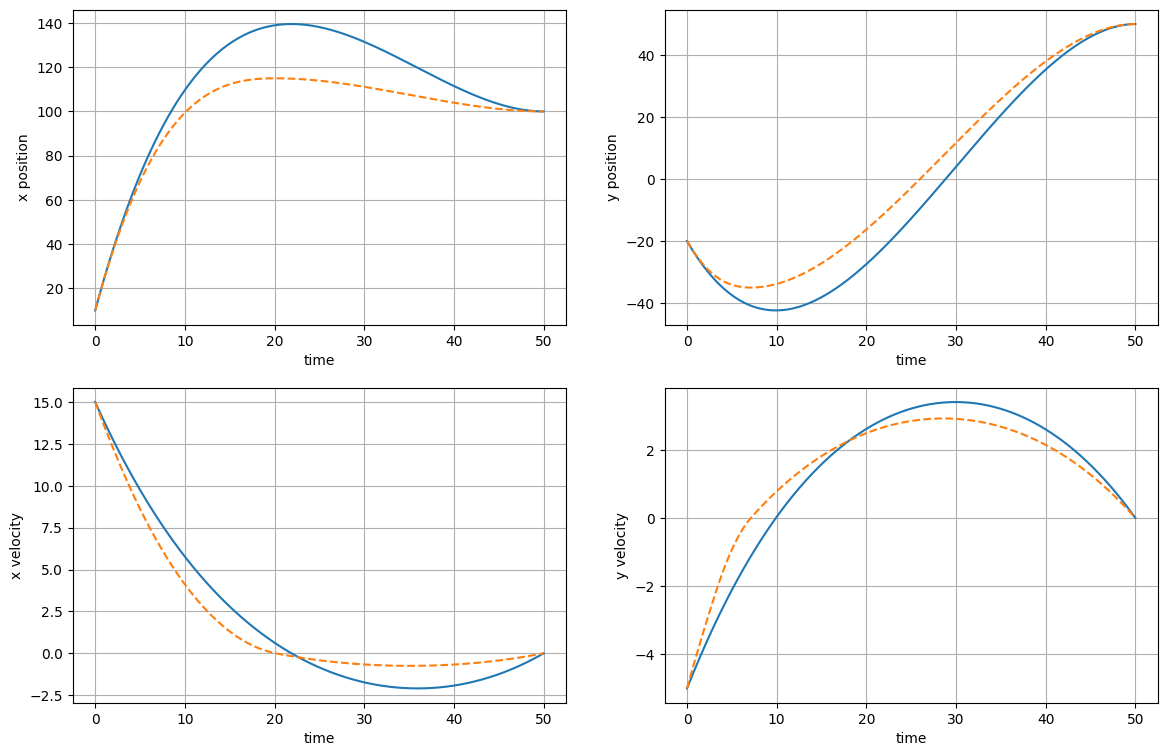

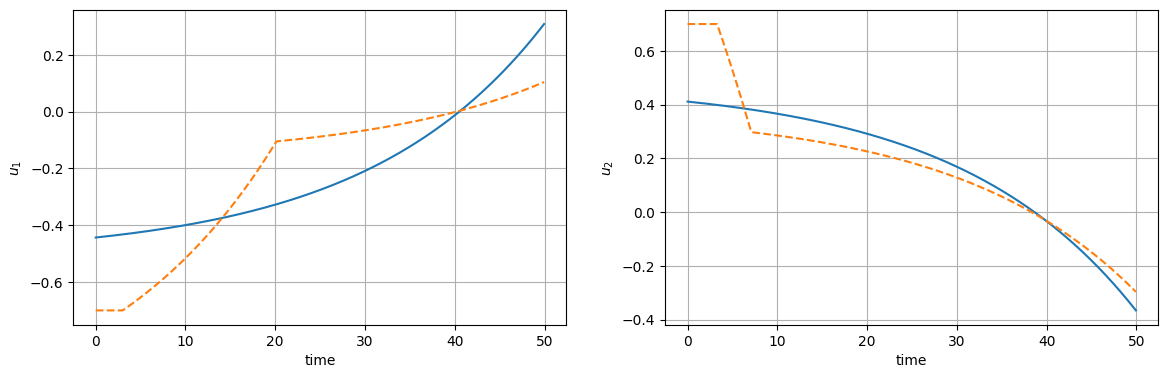

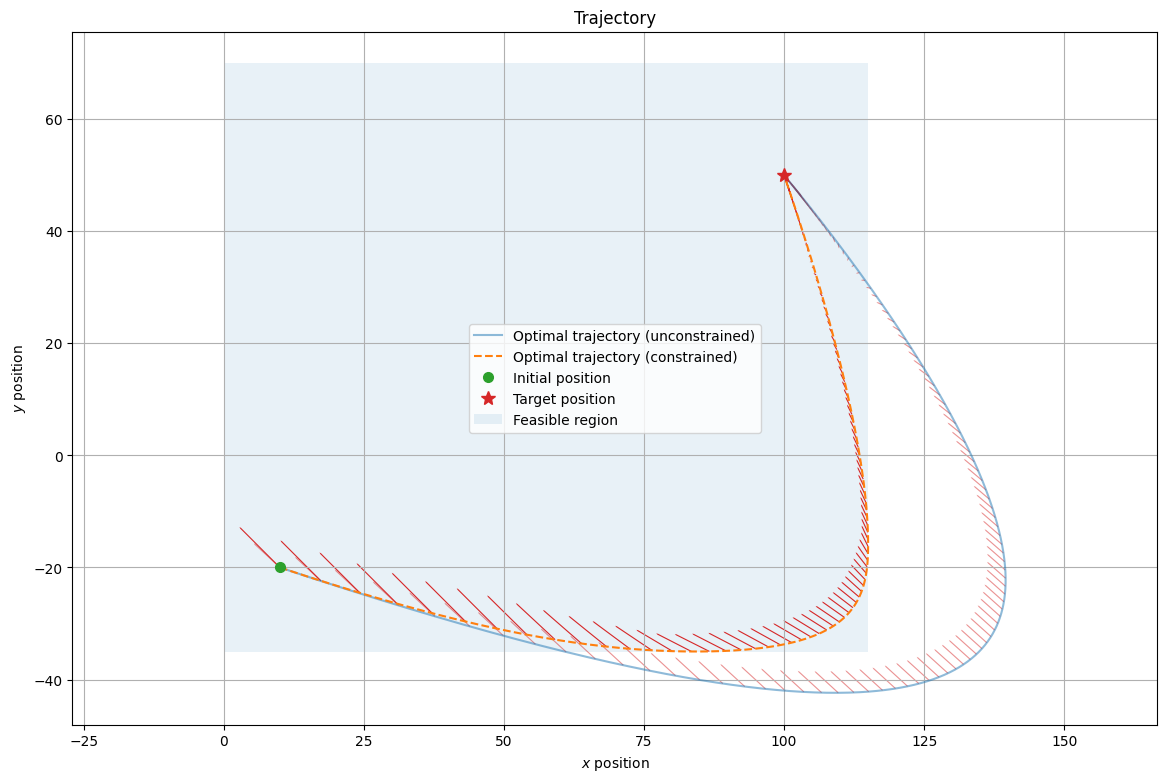

In [10]:
plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts,x_opt[0,:])
plt.plot(ts,x_cp[0,:], '--')
plt.xlabel('time')
plt.ylabel('x position')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts,x_opt[1,:])
plt.plot(ts,x_cp[1,:], '--')
plt.xlabel('time')
plt.ylabel('y position')
plt.grid()
plt.subplot(2,2,3)
plt.plot(ts,x_opt[2,:])
plt.plot(ts,x_cp[2,:], '--')
plt.xlabel('time')
plt.ylabel('x velocity')
plt.grid()
plt.subplot(2,2,4)
plt.plot(ts,x_opt[3,:])
plt.plot(ts,x_cp[3,:], '--')
plt.xlabel('time')
plt.ylabel('y velocity')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts[:-1],u_opt[0,:])
plt.plot(ts[:-1],u_cp[0,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts[:-1],u_opt[1,:])
plt.plot(ts[:-1],u_cp[1,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_2$')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.plot(x_opt[0,:],x_opt[1,:], label='Optimal trajectory (unconstrained)', alpha=0.5)
plt.plot(x_cp[0,:],x_cp[1,:], '--', label='Optimal trajectory (constrained)')
plt.plot(x_0[0], x_0[1], 'o', markersize=7, label='Initial position')
plt.plot(x_des[0], x_des[1], '*', markersize=10, label='Target position')
plt.broken_barh([(p_lb[0], p_ub[0])], (p_lb[1], p_ub[1]-p_lb[1]), \
                alpha = 0.1, label='Feasible region')
plt.title('Trajectory')
plt.legend()
for i in range(0,N-1,10):
  plt.arrow(x_opt[0,i], x_opt[1,i], 10*u_opt[0,i], 10*u_opt[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none', alpha=0.5)
  plt.arrow(x_cp[0,i], x_cp[1,i], 10*u_cp[0,i], 10*u_cp[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none')
plt.axis('equal')
plt.xlabel(r'$x$ position')
plt.ylabel(r'$y$ position')
plt.grid()
plt.show()

<br>

---

## Minimum 'something else' optimal control

We come back to the unconstrained problem.  We will consider different objective functions, in order to examine how the different objectives affect your optimal solutions.

First consider the sum (not squared-sum) of the 2-norm of $u_t$, which can be seen as the $\ell_1$ norm of $\left(\|u_0\|_2, \dots, \|u_{N-1}\|_2\right)$.
Note that the $\ell_1$ norm of  $\left( \|u_0\|_2, \dots, \|u_{N-1}\|_2 \right)$ is $\|u_0\|_2 + \cdots + \|u_{N-1}\|_2$ and the $\ell_2$ norm of  $\left( \|u_0\|_2, \dots, \|u_{N-1}\|_2 \right)$ is $\left(\|u_0\|_2^2 + \cdots + \|u_{N-1}\|_2^2\right)^{1/2}$

$$
\begin{aligned}
  \underset{u_0,\dots,u_{N-1}, x_1,\dots,x_N}{\minimize} \quad & \sum_{t=0}^{N-1} \|u_t\|_2  \\
  \text{subject to} \quad & x_N = x_{\text{des}} \\
  \quad & x_{t+1} = Ax_t + Bu_t, \qquad & t=0,\dots,N-1 \\
  & p_\text{lb} \le C x_t \le p_\text{ub}, \qquad & t=1,\dots,N \\
  & u_\text{lb} \le u_t \le u_\text{ub}, \qquad & t=0,\dots,N-1
\end{aligned}
$$

In [11]:
import cvxpy as cp

u_lb = np.array([-1, -1])*0.7
u_ub = np.array([ 1,  1])*0.7
p_lb = np.array([  0, -35])
p_ub = np.array([115,  70])
C = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

x = cp.Variable((4,N+1))  # x_{0},...,x_{N}
u = cp.Variable((2,N))    # u_{0},...,u_{N-1}

#############################
obj = cp.norm(cp.norm(u,2,axis=0),1)
#############################
obj = cp.Minimize(obj)

constr = [ x[:,-1] == x_des,
           x[:,0]  == x_0    ]
for t in range(N):
    constr += [ x[:,t+1] == A@x[:,t] + B@u[:,t] ]
    constr += [ p_lb <= C@x[:,t+1], C@x[:,t+1] <= p_ub ]
    ############################################
    constr += [ u_lb <= u[:,t], u[:,t] <= u_ub ]
    ############################################

cp.Problem(obj, constr).solve(verbose=True)

x_cp = np.array(x.value)
u_cp = np.array(u.value)

x_l1, u_l1 = x_cp, u_cp

(CVXPY) May 18 02:26:51 PM: Your problem has 6004 variables, 12008 constraints, and 0 parameters.
(CVXPY) May 18 02:26:51 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 18 02:26:51 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 18 02:26:51 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 18 02:26:51 PM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.7.3                                    


(CVXPY) May 18 02:26:51 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) May 18 02:26:51 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) May 18 02:26:51 PM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 18 02:26:51 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 18 02:26:51 PM: Applying reduction ConeMatrixStuffing
(CVXPY) May 18 02:26:53 PM: Applying reduction CLARABEL
(CVXPY) May 18 02:26:53 PM: Finished problem compilation (took 2.270e+00 seconds).
(CVXPY) May 18 02:26:53 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 8004
  constraints   = 17008
  nnz(P)        = 0
  nnz(A)        = 29008
  cones (total) = 1002
    :        Zero = 1,  numel = 4008
    : Nonnegative = 1,  numel = 10000
    : SecondOrder = 1000,  numel = (3,3,3,3,...,3)

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  

(CVXPY) May 18 02:26:53 PM: Problem status: optimal
(CVXPY) May 18 02:26:53 PM: Optimal value: 2.945e+02
(CVXPY) May 18 02:26:53 PM: Compilation took 2.270e+00 seconds
(CVXPY) May 18 02:26:53 PM: Solver (including time spent in interface) took 9.536e-02 seconds


  0  +0.0000e+00  -2.2280e+05  2.23e+05  4.94e-01  3.40e-02  1.00e+00  6.86e+01   ------   
  1  +6.8476e+03  -4.8362e+04  8.06e+00  1.76e-01  7.60e-03  1.34e+01  2.50e+01  9.21e-01  
  2  +1.8758e+03  -1.3642e+04  8.27e+00  5.36e-02  1.93e-03  4.76e+00  8.59e+00  7.98e-01  
  3  +5.6482e+02  -3.9712e+03  8.03e+00  1.52e-02  4.87e-04  1.26e+00  2.81e+00  7.50e-01  
  4  +3.9267e+02  -1.2561e+03  4.20e+00  4.93e-03  1.43e-04  3.52e-01  1.11e+00  8.14e-01  
  5  +2.9210e+02  -2.1999e+02  2.33e+00  1.41e-03  4.15e-05  9.08e-02  3.70e-01  8.36e-01  
  6  +3.0062e+02  -2.9883e+01  1.11e+01  9.08e-04  2.72e-05  5.27e-02  2.42e-01  6.48e-01  
  7  +2.9627e+02  +3.7183e+01  6.97e+00  7.11e-04  2.14e-05  3.92e-02  1.91e-01  4.57e-01  
  8  +2.9531e+02  +2.1898e+02  3.49e-01  2.08e-04  6.32e-06  1.14e-02  5.74e-02  7.24e-01  
  9  +2.9478e+02  +2.6480e+02  1.13e-01  8.26e-05  2.51e-06  4.40e-03  2.26e-02  6.51e-01  
 10  +2.9442e+02  +2.7937e+02  5.39e-02  4.16e-05  1.26e-06  2.11e-03  1.14e-02 

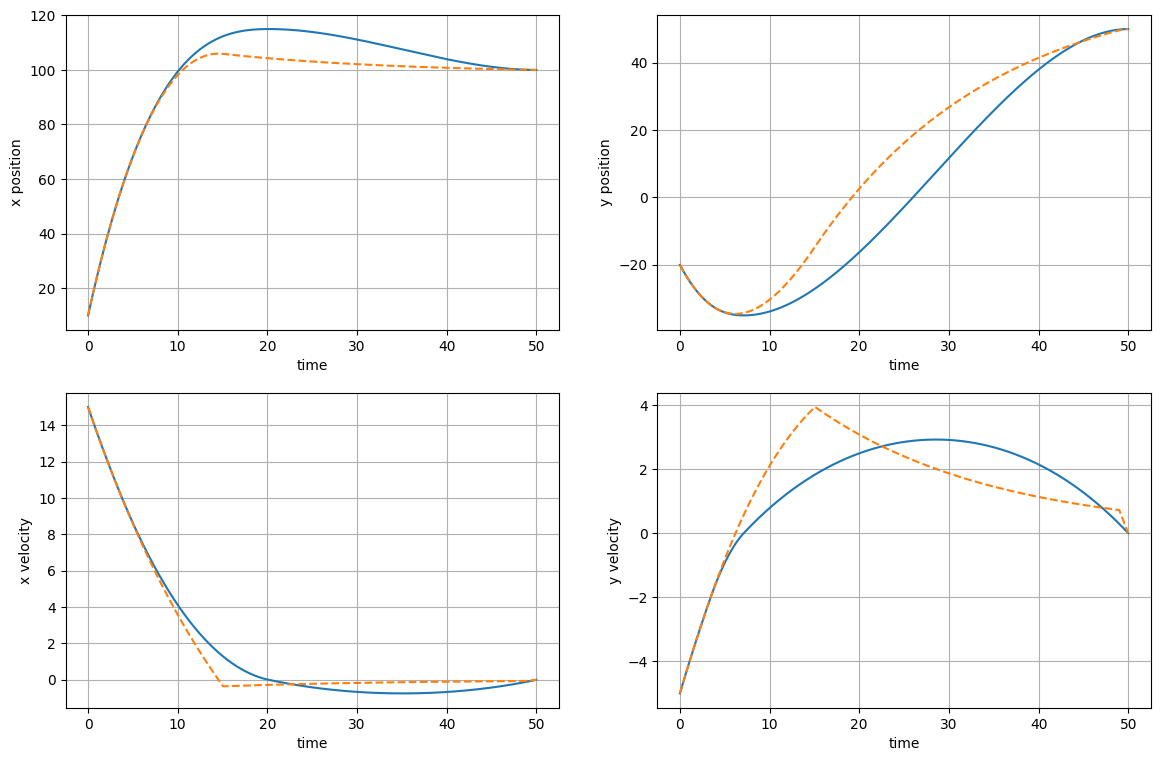

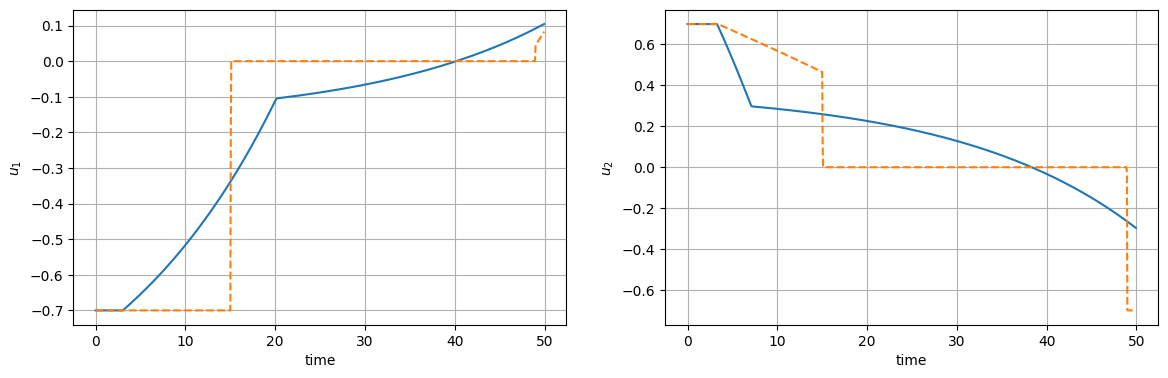

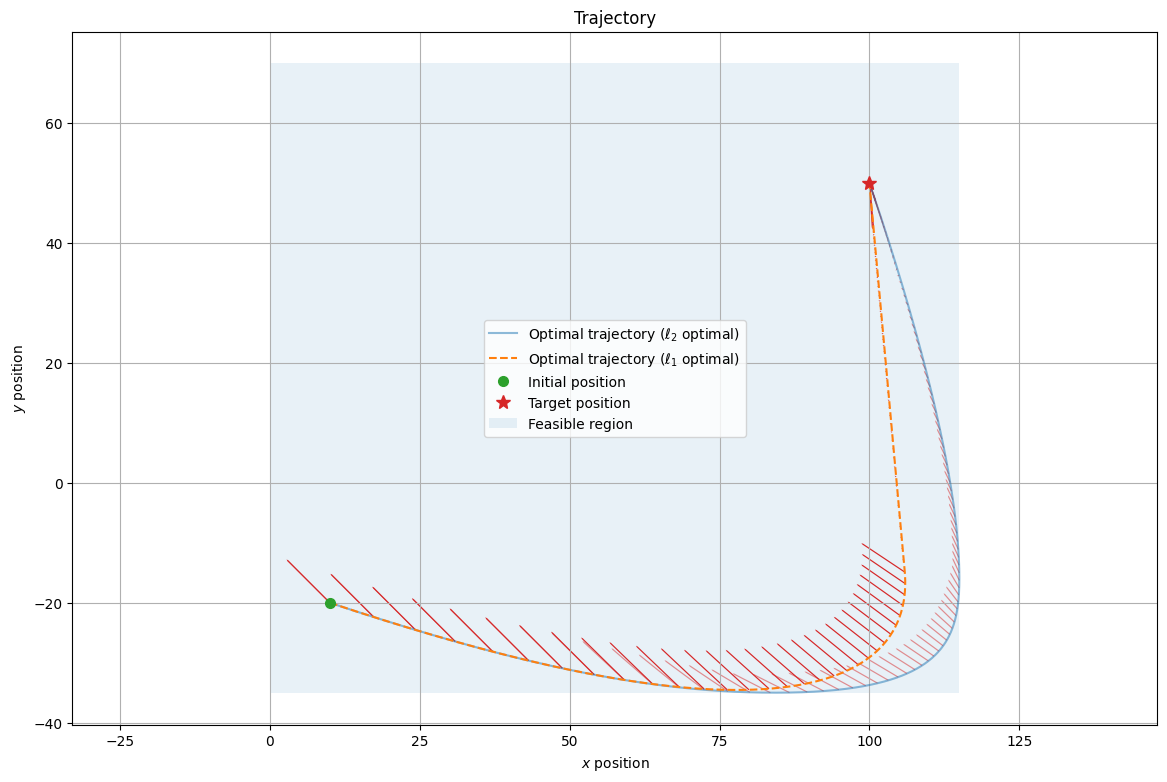

In [12]:
plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts,x_l2[0,:])
plt.plot(ts,x_l1[0,:], '--')
plt.xlabel('time')
plt.ylabel('x position')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts,x_l2[1,:])
plt.plot(ts,x_l1[1,:], '--')
plt.xlabel('time')
plt.ylabel('y position')
plt.grid()
plt.subplot(2,2,3)
plt.plot(ts,x_l2[2,:])
plt.plot(ts,x_l1[2,:], '--')
plt.xlabel('time')
plt.ylabel('x velocity')
plt.grid()
plt.subplot(2,2,4)
plt.plot(ts,x_l2[3,:])
plt.plot(ts,x_l1[3,:], '--')
plt.xlabel('time')
plt.ylabel('y velocity')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts[:-1],u_l2[0,:])
plt.plot(ts[:-1],u_l1[0,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts[:-1],u_l2[1,:])
plt.plot(ts[:-1],u_l1[1,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_2$')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.plot(x_l2[0,:],x_l2[1,:], label=r'Optimal trajectory ($\ell_2$ optimal)', alpha=0.5)
plt.plot(x_l1[0,:],x_l1[1,:], '--', label=r'Optimal trajectory ($\ell_1$ optimal)')
plt.plot(x_0[0], x_0[1], 'o', markersize=7, label='Initial position')
plt.plot(x_des[0], x_des[1], '*', markersize=10, label='Target position')
plt.broken_barh([(p_lb[0], p_ub[0])], (p_lb[1], p_ub[1]-p_lb[1]), \
                alpha = 0.1, label='Feasible region')
plt.title('Trajectory')
plt.legend()
for i in range(0,N-1,10):
  plt.arrow(x_l2[0,i], x_l2[1,i], 10*u_l2[0,i], 10*u_l2[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none', alpha=0.5)
  plt.arrow(x_l1[0,i], x_l1[1,i], 10*u_l1[0,i], 10*u_l1[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none')
plt.axis('equal')
plt.xlabel(r'$x$ position')
plt.ylabel(r'$y$ position')
plt.grid()
plt.show()

<br>

How about the maximum of the 2-norm of $u_t$, which can be seen as the $\ell_{\infty}$ norm of $\left(\|u_0\|_2, \dots, \|u_{N-1}\|_2\right)$.
$$
\begin{aligned}
  \underset{u_0,\dots,u_{N-1}, x_1,\dots,x_N}{\minimize} \quad & \max_t \|u_t\|_2  \\
  \text{subject to} \quad & x_N = x_{\text{des}} \\
  \quad & x_{t+1} = Ax_t + Bu_t, \qquad & t=0,\dots,N-1 \\
  & p_\text{lb} \le C x_t \le p_\text{ub}, \qquad & t=1,\dots,N \\
  & u_\text{lb} \le u_t \le u_\text{ub}, \qquad & t=0,\dots,N-1
\end{aligned}
$$

In [19]:
import cvxpy as cp

u_lb = np.array([-1, -1])*0.7
u_ub = np.array([ 1,  1])*0.7
p_lb = np.array([  0, -35])
p_ub = np.array([115,  70])
C = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])

x = cp.Variable((4,N+1))  # x_{0},...,x_{N}
u = cp.Variable((2,N))    # u_{0},...,u_{N-1}

################################################
obj = cp.max(cp.norm(u, 2, axis=0))
# obj += 1e-4*cp.norm(cp.norm(u, 2, axis=0),1)
obj = cp.Minimize(obj)
################################################

constr = [ x[:,-1] == x_des,
           x[:,0]  == x_0    ]
for t in range(N):
    constr += [ x[:,t+1] == A@x[:,t] + B@u[:,t] ]
    constr += [ p_lb <= C@x[:,t+1], C@x[:,t+1] <= p_ub ]
    constr += [ u_lb <= u[:,t], u[:,t] <= u_ub ]

cp.Problem(obj, constr).solve(verbose=True)

x_cp = np.array(x.value)
u_cp = np.array(u.value)

x_li, u_li = x_cp, u_cp

(CVXPY) May 18 02:27:23 PM: Your problem has 6004 variables, 12008 constraints, and 0 parameters.
(CVXPY) May 18 02:27:23 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 18 02:27:23 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 18 02:27:23 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 18 02:27:23 PM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.7.3                                    


(CVXPY) May 18 02:27:23 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) May 18 02:27:23 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> CLARABEL
(CVXPY) May 18 02:27:23 PM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) May 18 02:27:24 PM: Applying reduction CvxAttr2Constr
(CVXPY) May 18 02:27:24 PM: Applying reduction ConeMatrixStuffing
(CVXPY) May 18 02:27:25 PM: Applying reduction CLARABEL
(CVXPY) May 18 02:27:26 PM: Finished problem compilation (took 2.400e+00 seconds).
(CVXPY) May 18 02:27:26 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 7005
  constraints   = 16008
  nnz(P)        = 0
  nnz(A)        = 27008
  cones (total) = 1002
    :        Zero = 1,  numel = 4008
    : Nonnegative = 1,  numel = 9000
    : SecondOrder = 1000,  numel = (3,3,3,3,...,3)

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  s

(CVXPY) May 18 02:27:26 PM: Problem status: optimal
(CVXPY) May 18 02:27:26 PM: Optimal value: 8.445e-01
(CVXPY) May 18 02:27:26 PM: Compilation took 2.400e+00 seconds
(CVXPY) May 18 02:27:26 PM: Solver (including time spent in interface) took 1.262e-01 seconds


  0  +0.0000e+00  -2.2280e+05  2.23e+05  4.79e-01  4.85e-01  1.00e+00  6.68e+01   ------   
  1  +3.3886e+01  -1.2832e+05  3.79e+03  3.25e-01  2.59e-01  1.23e+01  4.43e+01  5.42e-01  
  2  +5.4282e+01  -3.2324e+04  5.96e+02  9.82e-02  5.72e-02  6.63e+00  1.45e+01  7.55e-01  
  3  +5.7724e+01  -1.0383e+04  1.81e+02  3.23e-02  1.66e-02  2.31e+00  5.19e+00  7.41e-01  
  4  +5.3141e+01  -2.8262e+03  5.42e+01  8.67e-03  4.06e-03  5.77e-01  1.61e+00  7.69e-01  
  5  +3.9761e+01  -5.5407e+02  1.49e+01  1.67e-03  7.79e-04  8.88e-02  3.97e-01  7.90e-01  
  6  +1.5853e+01  -2.5979e+01  2.64e+00  1.16e-04  5.98e-05  3.30e-03  3.44e-02  9.27e-01  
  7  +1.8342e+00  -2.7343e+00  2.49e+00  1.26e-05  6.75e-06  3.62e-04  4.06e-03  8.83e-01  
  8  +1.0629e+00  -9.9133e-01  2.05e+00  5.57e-06  2.96e-06  1.79e-04  1.84e-03  7.03e-01  
  9  +1.0423e+00  -3.5650e-01  1.40e+00  3.77e-06  2.00e-06  1.25e-04  1.25e-03  4.35e-01  
 10  +9.2190e-01  +2.6643e-01  6.55e-01  1.74e-06  9.23e-07  6.24e-05  5.86e-04 

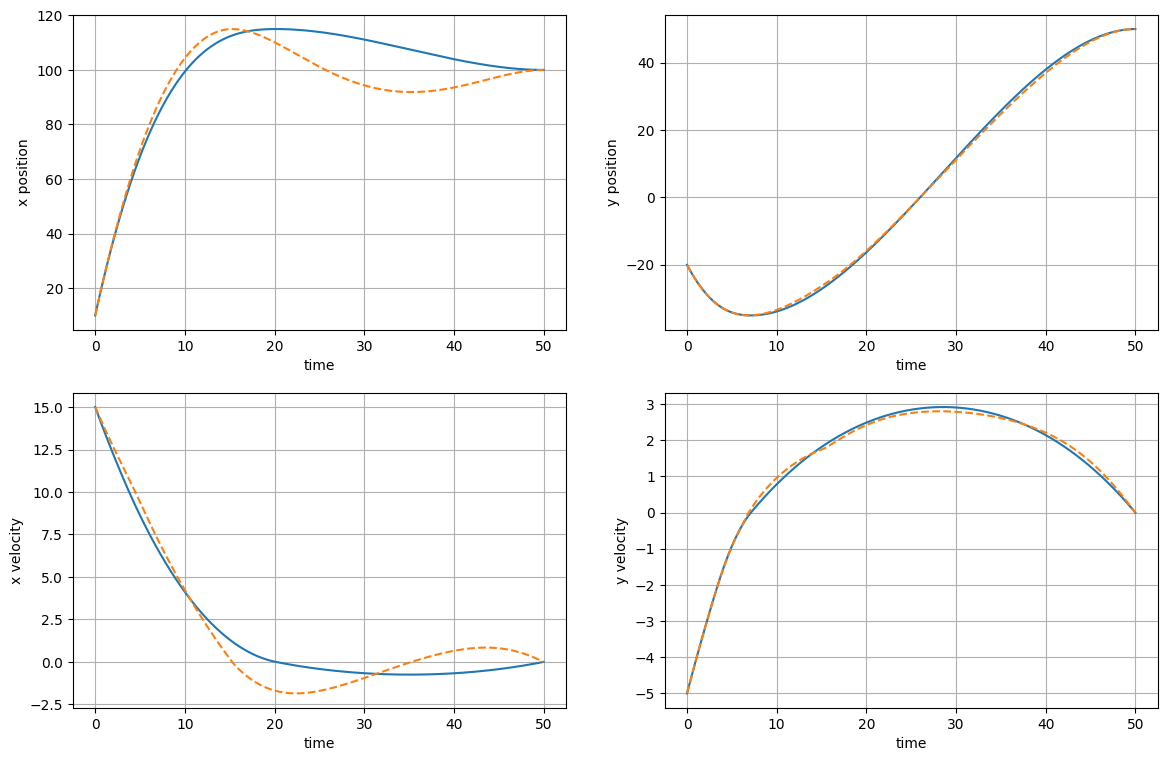

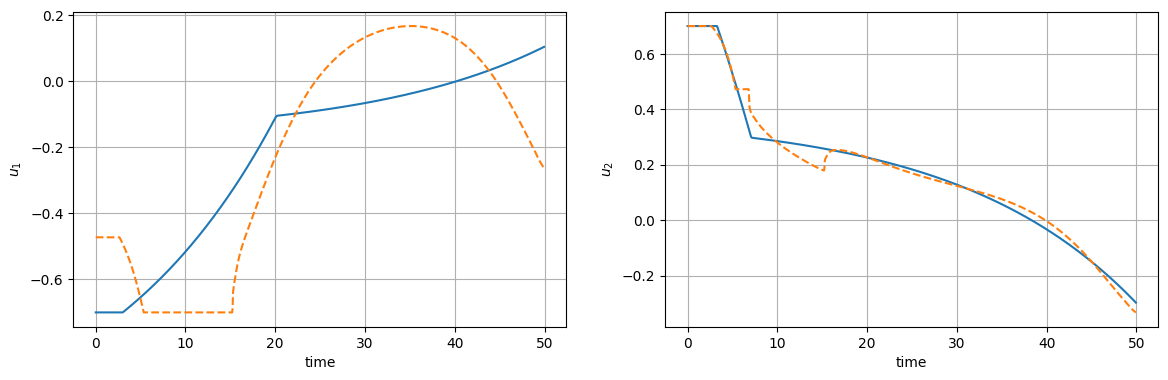

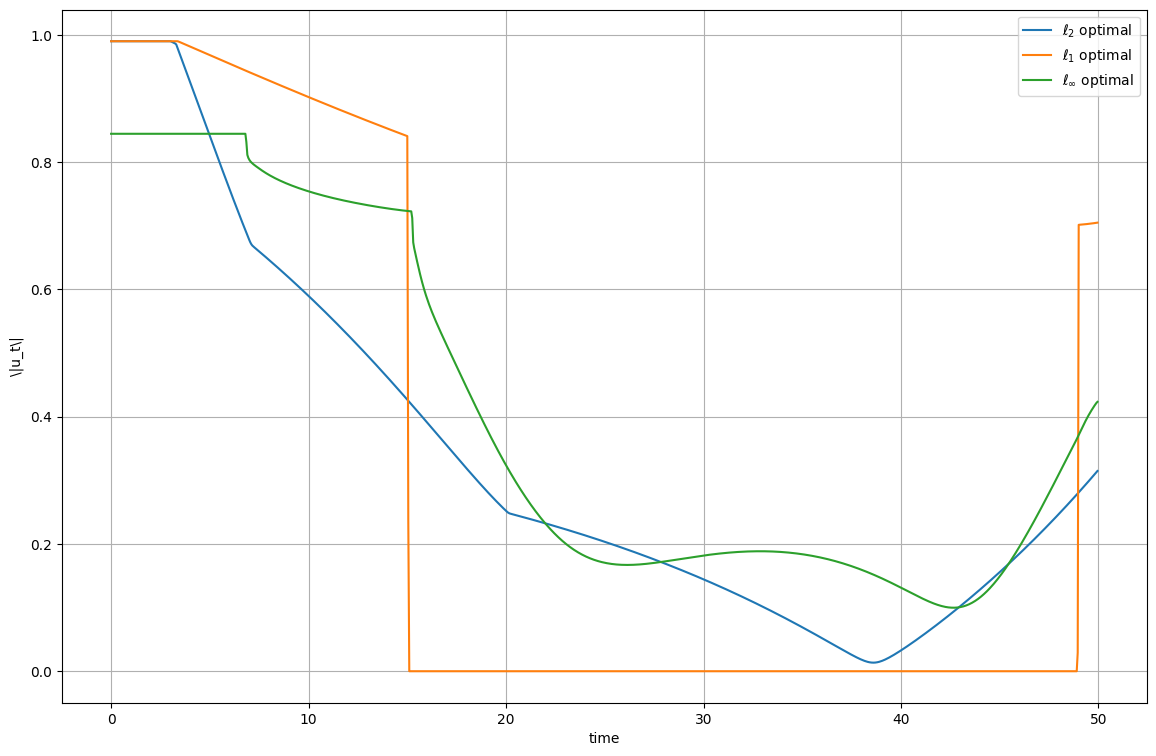

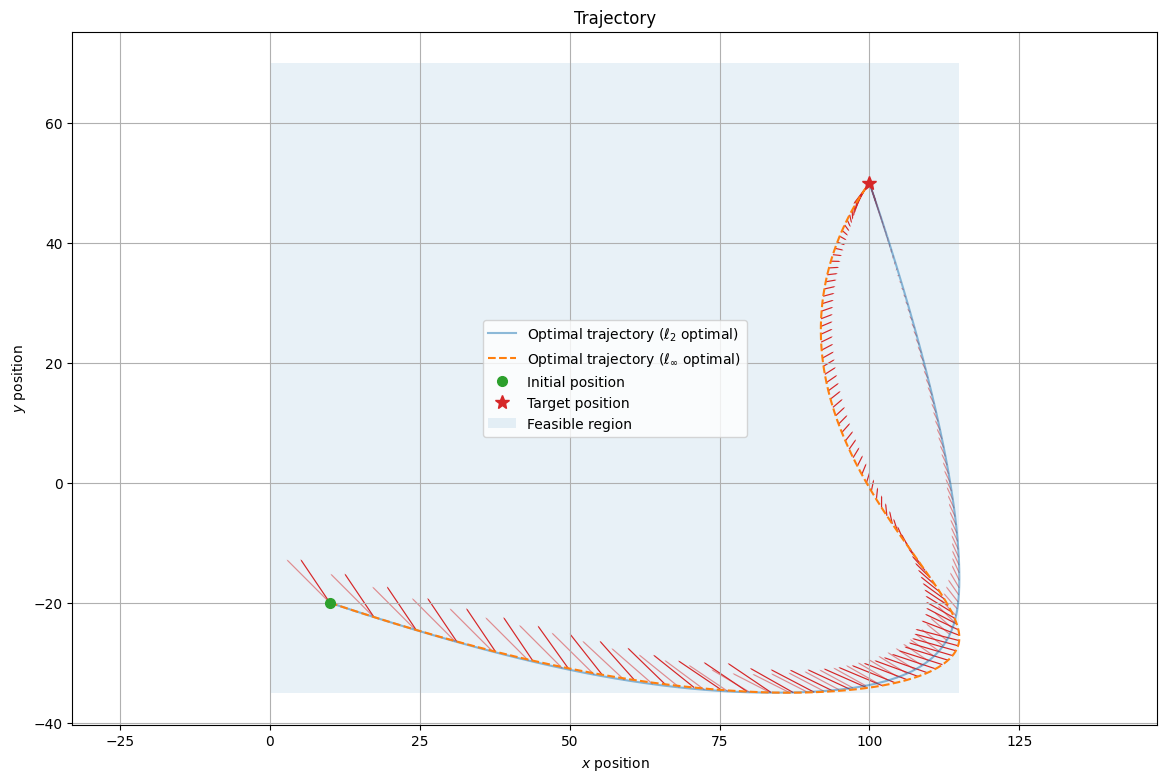

In [20]:
plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts,x_l2[0,:])
plt.plot(ts,x_li[0,:], '--')
plt.xlabel('time')
plt.ylabel('x position')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts,x_l2[1,:])
plt.plot(ts,x_li[1,:], '--')
plt.xlabel('time')
plt.ylabel('y position')
plt.grid()
plt.subplot(2,2,3)
plt.plot(ts,x_l2[2,:])
plt.plot(ts,x_li[2,:], '--')
plt.xlabel('time')
plt.ylabel('x velocity')
plt.grid()
plt.subplot(2,2,4)
plt.plot(ts,x_l2[3,:])
plt.plot(ts,x_li[3,:], '--')
plt.xlabel('time')
plt.ylabel('y velocity')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,2,1)
plt.plot(ts[:-1],u_l2[0,:])
plt.plot(ts[:-1],u_li[0,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.grid()
plt.subplot(2,2,2)
plt.plot(ts[:-1],u_l2[1,:])
plt.plot(ts[:-1],u_li[1,:], '--')
plt.xlabel('time')
plt.ylabel(r'$u_2$')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.plot(ts[:-1],np.linalg.norm(u_l2,2,axis=0), label=r'$\ell_2$ optimal')
plt.plot(ts[:-1],np.linalg.norm(u_l1,2,axis=0), label=r'$\ell_1$ optimal')
plt.plot(ts[:-1],np.linalg.norm(u_li,2,axis=0), label=r'$\ell_\infty$ optimal')
plt.xlabel('time')
plt.ylabel(r'\|u_t\|')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.plot(x_l2[0,:],x_l2[1,:], label=r'Optimal trajectory ($\ell_2$ optimal)', alpha=0.5)
plt.plot(x_li[0,:],x_li[1,:], '--', label=r'Optimal trajectory ($\ell_\infty$ optimal)')
plt.plot(x_0[0], x_0[1], 'o', markersize=7, label='Initial position')
plt.plot(x_des[0], x_des[1], '*', markersize=10, label='Target position')
plt.broken_barh([(p_lb[0], p_ub[0])], (p_lb[1], p_ub[1]-p_lb[1]), \
                alpha = 0.1, label='Feasible region')
plt.title('Trajectory')
plt.legend()
for i in range(0,N-1,10):
  plt.arrow(x_l2[0,i], x_l2[1,i], 10*u_l2[0,i], 10*u_l2[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none', alpha=0.5)
  plt.arrow(x_li[0,i], x_li[1,i], 10*u_li[0,i], 10*u_li[1,i], head_width=0.2, width=0.2, fc='tab:red', ec='none')
plt.axis('equal')
plt.xlabel(r'$x$ position')
plt.ylabel(r'$y$ position')
plt.grid()
plt.show()

<br>

---

In order to get a better intuition behind these effects, let us consider a 1 dimensional unconstrained problem.


In [15]:
N = 1000 # number of timesteps
T = 50 # time will vary from 0 to T with step delt
ts = np.linspace(0,T,N+1)
delt = T/N
gamma = .0 # damping, 0 is no damping

A1 = np.zeros((2,2))
B1 = np.zeros((2,1))
C1 = np.zeros((1,2))

A1[0,0] = 1
A1[0,1] = (1-gamma*delt/2)*delt
A1[1,1] = 1 - gamma*delt

B1[0,0] = delt**2/2
B1[1,0] = delt

x_01 = np.array([0, 0])
x_des1 = np.array([100, 0])

In [16]:
import cvxpy as cp

x = cp.Variable((2,N+1))  # x_{0},...,x_{N}
u = cp.Variable((1,N))    # u_{0},...,u_{N-1}

obj2 = cp.Minimize(cp.norm(u))

constr = [ x[:,-1] == x_des1,
           x[:,0]  == x_01    ]
for t in range(N):
    constr += [ x[:,t+1] == A1@x[:,t] + B1@u[:,t] ]

cp.Problem(obj2, constr).solve()
x_cp2 = np.array(x.value)
u_cp2 = np.array(u.value)

obj1 = cp.Minimize(cp.norm1(u))
cp.Problem(obj1, constr).solve()
x_cp1 = np.array(x.value)
u_cp1 = np.array(u.value)

obji = cp.Minimize(cp.norm_inf(u))
cp.Problem(obji, constr).solve()
x_cpi = np.array(x.value)
u_cpi = np.array(u.value)

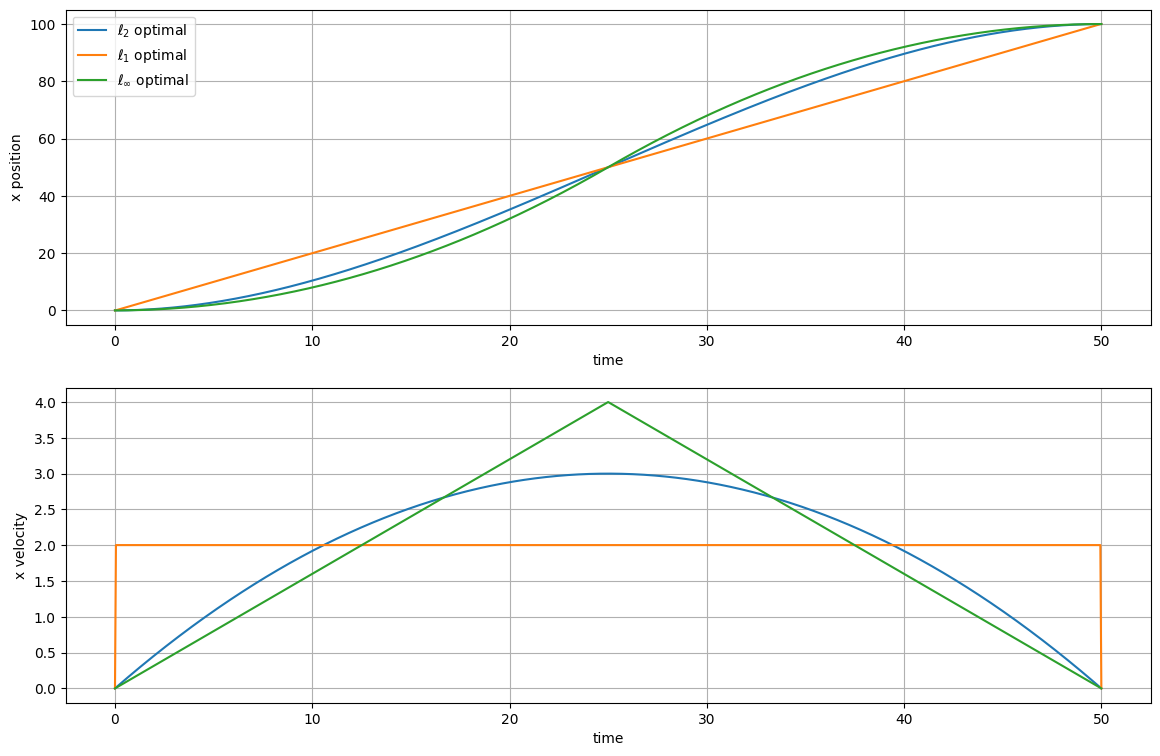

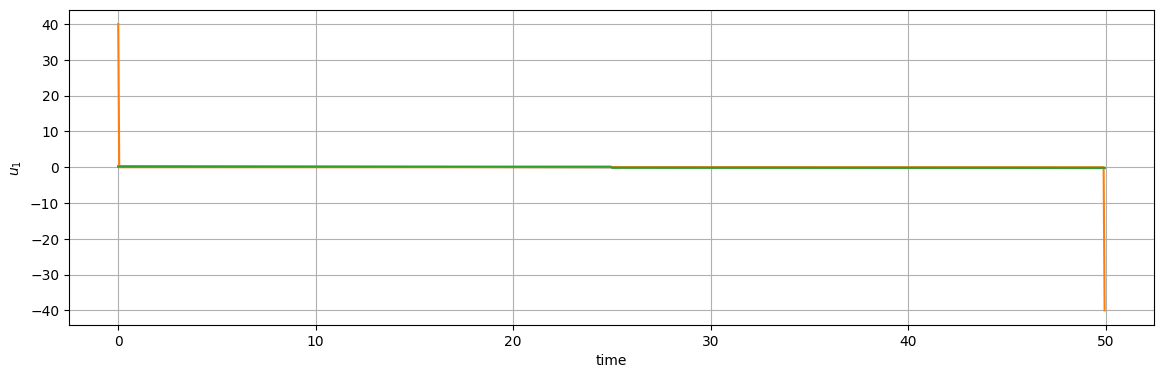

In [17]:
plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,1,1)
plt.plot(ts,x_cp2[0,:], label=r'$\ell_2$ optimal')
plt.plot(ts,x_cp1[0,:], label=r'$\ell_1$ optimal')
plt.plot(ts,x_cpi[0,:], label=r'$\ell_\infty$ optimal')
plt.xlabel('time')
plt.ylabel('x position')
plt.legend()
plt.grid()
plt.subplot(2,1,2)
plt.plot(ts,x_cp2[1,:], label=r'$\ell_2$ optimal')
plt.plot(ts,x_cp1[1,:], label=r'$\ell_1$ optimal')
plt.plot(ts,x_cpi[1,:], label=r'$\ell_\infty$ optimal')
plt.xlabel('time')
plt.ylabel('x velocity')
plt.grid()
plt.show()

plt.figure(figsize=(14,9), dpi=100)
plt.subplot(2,1,1)
plt.plot(ts[:-1],u_cp2[0,:], label=r'$\ell_2$ optimal')
plt.plot(ts[:-1],u_cp1[0,:], label=r'$\ell_1$ optimal')
plt.plot(ts[:-1],u_cpi[0,:], label=r'$\ell_\infty$ optimal')
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.grid()
plt.show()

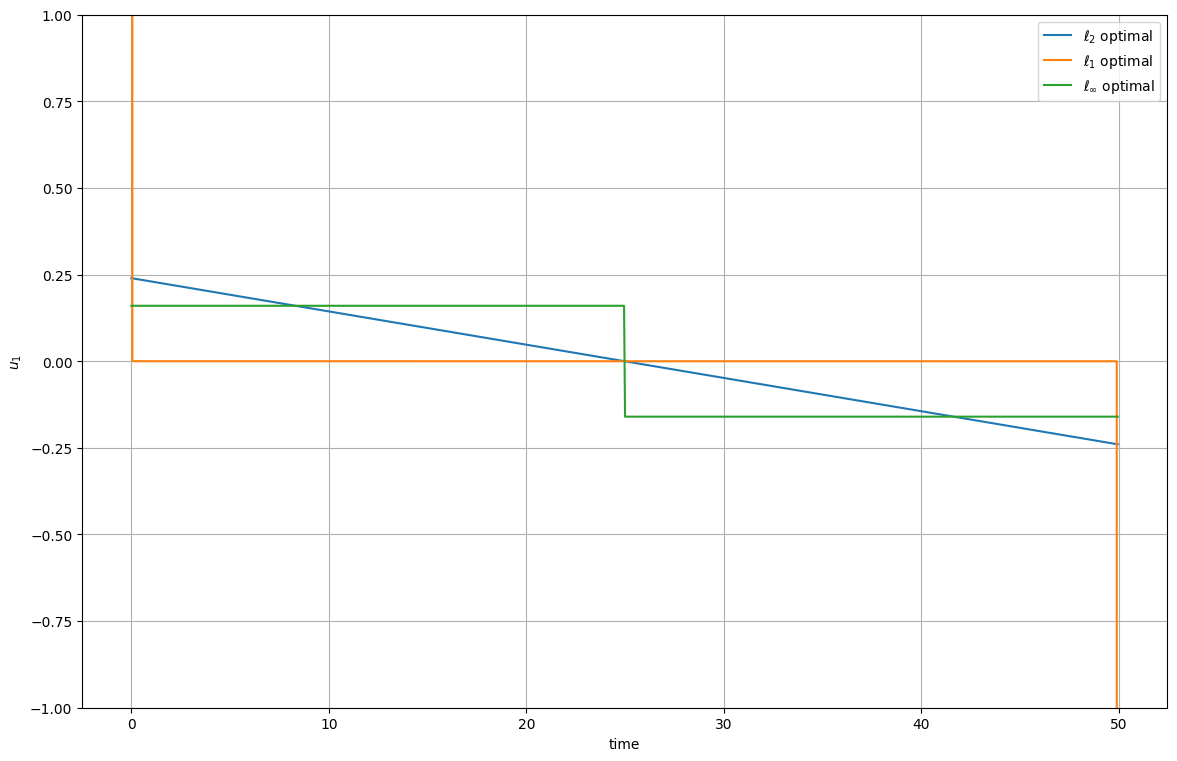

In [18]:
plt.figure(figsize=(14,9), dpi=100)
plt.plot(ts[:-1],u_cp2[0,:], label=r'$\ell_2$ optimal')
plt.plot(ts[:-1],u_cp1[0,:], label=r'$\ell_1$ optimal')
plt.plot(ts[:-1],u_cpi[0,:], label=r'$\ell_\infty$ optimal')
plt.xlabel('time')
plt.ylabel(r'$u_1$')
plt.legend()
plt.ylim(-1, 1)
plt.grid()
plt.show()